# QPANN Part 3: Model Building, Synthetic Data, and Training

This is **Part 3** of the 3-part Quantum Physics-Aware Neural Network (QPANN) tutorial series.

In Parts 1 & 2, we mastered error generator bookkeeping, circuit encoding, Clifford error propagation, and locality snippers. In this final tutorial, we will:
1. **Build a QPANN Model:** Instantiate the model in Keras and perform an untrained forward pass.
2. **Generate Synthetic Ground-Truth Data:** Build a physically realistic noisy device simulator using a global idle gate and compute exact outcome probabilities.
3. **Train the QPANN:** Train the model using Keras's standard optimizer and loss workflow.
4. **Extract and Validate Learned Rates:** Compare the learned error rates against our injected true rates to prove the network successfully characterized the device.

---
## 1. The QPANN Keras Model

A `QPANN` object is a subclass of `keras.Model`. It takes as input a list of three tensors:
`x = [circuits_tensor, alphas, probabilities_ideal]`
which matches the `'concise'` probability-computation mode (the default).

Let's instantiate the model and run an untrained forward pass. Since the weights are initialized close to zero, the untrained network should predict outcome probabilities that are very close to the ideal, noise-free probabilities.

In [4]:
import numpy as np
import tensorflow as tf
import keras
import pygsti
from pygsti.processors.processorspec import QubitProcessorSpec as QPS
from pygsti.circuits import Circuit
from pygsti.extras.ml import encoding, errgentools as et, snippers, qpanns

In [ ]:
# 1. Simple 2-qubit setup
qubit_labels = [0, 1]
pspec = QPS(num_qubits=2, qubit_labels=qubit_labels, gate_names=['Gxpi2', 'Gypi2'], availability={})
circuits = [
    Circuit('[Gxpi2:0Gypi2:1]@(0,1)'),
    Circuit('[Gypi2:0][Gxpi2:1]@(0,1)')
]

print("Example circuits:")
for i, circuit in enumerate(circuits):
    print(f"  Circuit {i}: ")
    print(f"{circuit}")
    
modelled_error_generators = [('H', ('XI',)), ('S', ('IX',))]

# 2. Build inputs
encoder = encoding.StandardCircuitEncoder(pspec)
circuits_tensor = encoding.circuits_to_tensor(circuits, encoder)
tensors = encoding.error_generator_tensors(circuits, modelled_error_generators, pspec, alpha_representation='concise')
probabilities_ideal, alphas = tensors['probabilities'], tensors['alphas']

# 3. Build snipper & QPANN
adjacency_matrix = snippers.undirected_adjacency_matrix_from_edges([(0, 1)], [0, 1])
snipper = snippers.layer_snipper_from_qubit_graph(modelled_error_generators, encoder, adjacency_matrix, hops=1)

qpann = qpanns.QPANN(encoder.length, modelled_error_generators, snipper)

# 4. Untrained forward pass
x = [circuits_tensor, alphas, probabilities_ideal]
output = qpann(x)
print("Untrained model output shape:", output.shape, " (num_circuits, 2**n)")
print("Untrained predictions for Circuit 0:\n", output[0].numpy())
print("Ideal noise-free probabilities for Circuit 0:\n", probabilities_ideal[0])

Example circuits:
  Circuit 0: 
Qubit 0 ---|Gxpi2|---
Qubit 1 ---|Gypi2|---

  Circuit 1: 
Qubit 0 ---|Gypi2|-|     |---
Qubit 1 ---|     |-|Gxpi2|---



100%|██████████| 2/2 [00:00<00:00, 593.21it/s]

Untrained model output shape: (2, 4)  (num_circuits, 2**n)
Untrained predictions for Circuit 0:
 [0.25000486 0.25000486 0.24999514 0.24999514]
Ideal noise-free probabilities for Circuit 0:
 [0.25 0.25 0.25 0.25]


---
## 2. Generating Synthetic Ground-Truth Data

To demonstrate training, we need a dataset where the "true" underlying physical error rates are known. We'll construct a physically realistic noisy device using pyGSTi's crosstalk model:
1. We add a synthetic n-qubit global idle gate (`'Gidle'`) to our `ProcessorSpec`'s gate names.
2. We define a dictionary of known "true" error rates for our modeled generators and attach them to `'Gidle'`.
3. We build a `CloudNoiseModel` with `implicit_idle_mode='add_global'`, which composes this same noisy idle gate onto **every** circuit layer. This represents a constant-rate-per-layer noise model.
4. We generate 100 random circuits, simulate their exact (non-linearized) outcome probabilities, and use these as our training targets ($y$).

Let's set up this ground-truth generator and verify that our first-order alpha approximation is close to the exact simulation.

In [21]:
import pygsti
import itertools
from pygsti.algorithms.randomcircuit import create_random_circuit

RNG_SEED = 12345
num_qubits = 3
qubit_labels = [0, 1, 2]
gate_names = ['Gxpi2', 'Gypi2', 'Gcphase', 'Gidle']  # Gidle auto-detected as global idle
availability = {'Gcphase': [(0, 1), (1, 2), (2, 0)]}  # ring connectivity

pspec_3q = QPS(num_qubits=num_qubits, qubit_labels=qubit_labels,
               gate_names=gate_names, availability=availability)

# Define 4 "true" generators and their injected physical rates
true_error_generators = [
    ('H', ('XII',)),  # Coherent X error on qubit 0
    ('H', ('IYI',)),  # Coherent Y error on qubit 1
    ('S', ('XII',)),  # Stochastic X error on qubit 0
    ('S', ('IIX',)),  # Stochastic X error on qubit 2
]
true_rates = np.array([0.006, -0.004, 0.0012, 0.0008])

# Build the exact noisy CloudNoiseModel simulator
lindblad_error_coeffs = {
    'Gidle': {(eg[0], eg[1][0]): rate for eg, rate in zip(true_error_generators, true_rates)}
}
error_model = pygsti.models.create_cloud_crosstalk_model(
    pspec_3q, lindblad_error_coeffs=lindblad_error_coeffs,
    errcomp_type="errorgens", implicit_idle_mode='add_global'
)

# Sample 100 random circuits
rand_state = np.random.RandomState(RNG_SEED)
num_circuits = 100
circuits_3q = [
    create_random_circuit(pspec_3q, int(rand_state.randint(5, 13)), sampler='edgegrab',
                          samplerargs=[0.5], rand_state=rand_state)
    for _ in range(num_circuits)
]

# Simulate exact probabilities
nbit_strings = [''.join(p) for p in itertools.product('01', repeat=num_qubits)]
exact_probabilities = np.zeros((num_circuits, 2**num_qubits))
for i, circuit in enumerate(circuits_3q):
    probs_dict = error_model.probabilities(circuit)
    exact_probabilities[i, :] = [probs_dict[(bs,)] for bs in nbit_strings]

# Compute QPANN inputs (alphas and ideal probabilities)
tensors_3q = encoding.error_generator_tensors(
    circuits_3q, true_error_generators, pspec_3q, alpha_representation='concise'
)
probabilities_ideal_3q = tensors_3q['probabilities']
alphas_3q = tensors_3q['alphas']

# Verify first-order approximation
approx_probabilities = probabilities_ideal_3q + np.einsum('nbdg,g->nb', alphas_3q, true_rates)
abs_diff = np.abs(exact_probabilities - approx_probabilities)
print(f"Max exact-vs-first-order discrepancy over all 100 circuits: {abs_diff.max():.6f}")
print(f"Mean exact-vs-first-order discrepancy over all 100 circuits: {abs_diff.mean():.6f}")

100%|██████████| 100/100 [00:00<00:00, 205.21it/s]


Max exact-vs-first-order discrepancy over all 100 circuits: 0.001454
Mean exact-vs-first-order discrepancy over all 100 circuits: 0.000100


---
## 3. Training the QPANN

Now, let's build a QPANN for our 3-qubit device and train it against the simulated exact probabilities.

We will:
1. Encode the circuits into a tensor.
2. Build the graph-locality adjacency matrix and the snipper.
3. Instantiate the QPANN.
4. Compile the model with Mean Squared Error (MSE) loss, Adam optimizer, and `'R2Score'`/`'mae'` metrics.
5. Train with a train/validation split (80/20) and `EarlyStopping` to prevent overfitting.
6. Plot the loss curve using matplotlib.

Training QPANN...
Training finished after 57 epochs!
Final Validation R2 Score: 1.0000


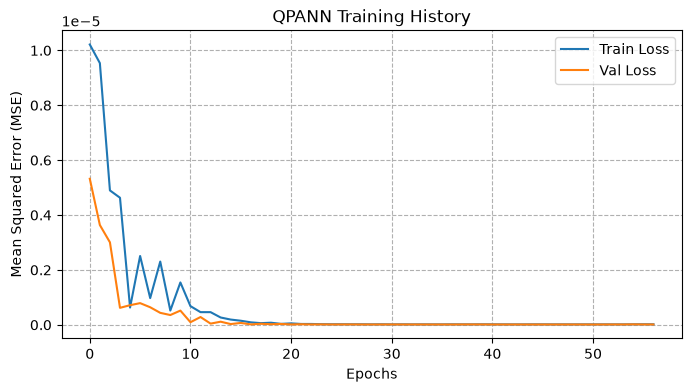

In [7]:
import matplotlib.pyplot as plt

# 1. Encode circuits to tensor
encoder_3q = encoding.StandardCircuitEncoder(pspec_3q)
circuits_tensor_3q = encoding.circuits_to_tensor(circuits_3q, encoder_3q)

# 2. Build snipper
adj_3q = snippers.undirected_adjacency_matrix_from_edges(availability['Gcphase'], qubit_labels)
snipper_3q = snippers.layer_snipper_from_qubit_graph(true_error_generators, encoder_3q, adj_3q, hops=1)

# 3. Build QPANN
model_3q = qpanns.QPANN(encoder_3q.length, true_error_generators, snipper_3q)
x_3q = [circuits_tensor_3q, alphas_3q, probabilities_ideal_3q]

# 4. Compile & Fit
model_3q.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3), loss='mse', metrics=['R2Score', 'mae'])
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_R2Score', patience=15, restore_best_weights=True)

print("Training QPANN...")
history = model_3q.fit(
    x_3q, exact_probabilities,
    epochs=120, batch_size=20, validation_split=0.2,
    callbacks=[early_stopping], verbose=0
)
print(f"Training finished after {len(history.history['loss'])} epochs!")
print(f"Final Validation R2 Score: {history.history['val_R2Score'][-1]:.4f}")

# 5. Plot training & validation loss curves
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('QPANN Training History')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

---
## 4. Extracting and Validating Learned Error Rates

Since our synthetic noisy device has a constant rate per layer, the QPANN's predicted error rates should also converge to be nearly constant across layers and match our injected true rates!

To inspect the learned error rates, we can pass a dummy circuit encoding (e.g. an all-zero vector, representing an idle layer, or any specific gate vector) through the model's trained `dense_layer` and print the outputs.

Let's extract these predicted rates, average them over layers, and plot them in a bar chart against our true injected values.

Error Generator        |  True Rate | Learned Rate | Absolute Error
--------------------------------------------------------------------
('H', ('XII',))        |     0.0060 |       0.0059 |         0.0001
('H', ('IYI',))        |    -0.0040 |      -0.0039 |         0.0001
('S', ('XII',))        |     0.0012 |       0.0013 |         0.0001
('S', ('IIX',))        |     0.0008 |       0.0008 |         0.0000


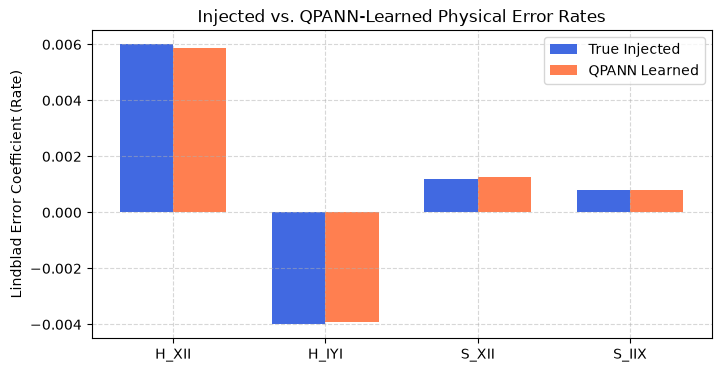

In [8]:
# 1. Call the dense rate-prediction layer on an active gate layer encoding
# We construct a simple test input of shape (1, encoder_3q.length) representing one layer of depth 1
test_inputs = tf.zeros((1, encoder_3q.length), dtype=tf.float32)
# dense_layer returns shape (1, num_generators) with a potential leading 1 axis -- see Gotcha #1 in qpanns.py!
predicted_rates_tensor = model_3q.dense_layer(test_inputs)
# Squeeze any extra dimensions of size 1 to get a clean 1D array of rates
learned_rates = tf.squeeze(predicted_rates_tensor).numpy()

print(f"{'Error Generator':<22s} | {'True Rate':>10s} | {'Learned Rate':>12s} | {'Absolute Error':>14s}")
print("-" * 68)
for eg, t_rate, l_rate in zip(true_error_generators, true_rates, learned_rates):
    abs_err = abs(t_rate - l_rate)
    print(f"{eg!r:<22s} | {t_rate:>10.4f} | {l_rate:>12.4f} | {abs_err:>14.4f}")

# 2. Plot comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x_indices = np.arange(len(true_error_generators))
bar_width = 0.35

ax.bar(x_indices - bar_width/2, true_rates, bar_width, label='True Injected', color='royalblue')
ax.bar(x_indices + bar_width/2, learned_rates, bar_width, label='QPANN Learned', color='coral')

ax.set_title('Injected vs. QPANN-Learned Physical Error Rates')
ax.set_xticks(x_indices)
ax.set_xticklabels([f"{eg[0]}_{eg[1][0]}" for eg in true_error_generators])
ax.set_ylabel('Lindblad Error Coefficient (Rate)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.show()

---
## Summary and Next Steps

Congratulations! You have successfully built, simulated, trained, and characterized a quantum device using a **Quantum Physics-Aware Neural Network (QPANN)** in pyGSTi.

### Key Takeaways:
* **Rate Recovery:** The QPANN was only given access to *circuits* and *measured outcome probabilities* (it never saw the true error rates directly). Yet, by utilizing efficient Clifford error propagation in its loss function, it accurately recovered the true underlying physical Lindblad error rates!
* **Generalizability:** Because the physics of Clifford propagation are hard-coded into the `ProbabilitiesLayerConcise` layer, the model's rate predictions are guaranteed to produce physically valid probabilities that obey quantum mechanics.
* **Interpretation:** The QPANN's weights are not black-box numbers—they have a direct, rigorous physical meaning representing device coherent over-rotations ('H') and incoherent stochastic noise ('S').

### Further Reading:
* Review the original [NeurIPS 2024 paper](https://arxiv.org/abs/2406.05636) for detailed benchmarks and high-qubit-count simulations.
* Explore the other parts of this series for deeper looks at [bookkeeping/encoding](QPANN-CircuitEncoding.ipynb) and [propagation/locality](QPANN-ErrorPropagation.ipynb).